### Modelado de Relaciones Lineales.

Se desea investigar la relación entre la edad de los pacientes (X) y sus niveles séricos de triglicéridos (Y). Estudios epidemiológicos sugieren que los niveles de triglicéridos aumentan de forma lineal indefinidamente.

In [1]:
# 1. Load visualization library
library(ggplot2)

# 2. Simulate Clinical Data
# Generating 120 patients with a general upward linear trend
set.seed(789)
n <- 120
age <- runif(n, 18, 85)
# Simulating a linear increase with significant biological noise
triglycerides <- 80 + (1.2 * age) + rnorm(n, 0, 35)

clinical_data <- data.frame(Age = age, Triglycerides = triglycerides)

# 3. Fit the Simple Linear Model
# The lm() function is the standard for linear modeling in R
linear_fit <- lm(Triglycerides ~ Age, data = clinical_data)

# 4. Extract Statistical Parameters
summary(linear_fit)


Call:
lm(formula = Triglycerides ~ Age, data = clinical_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-101.377  -20.839    1.334   22.268   99.710 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   63.683      9.582   6.646 9.81e-10 ***
Age            1.503      0.181   8.307 1.90e-13 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 36.05 on 118 degrees of freedom
Multiple R-squared:  0.369,	Adjusted R-squared:  0.3636 
F-statistic:    69 on 1 and 118 DF,  p-value: 1.897e-13


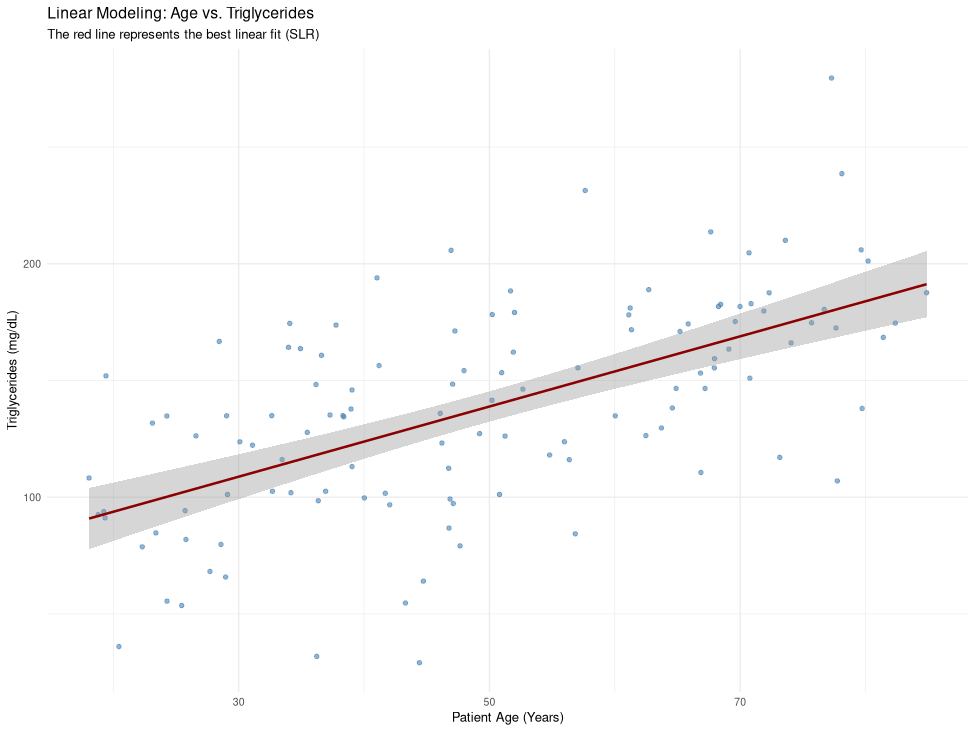

`geom_smooth()` using formula = 'y ~ x'

In [2]:
ggplot(clinical_data, aes(x = Age, y = Triglycerides)) +
  geom_point(color = "steelblue", alpha = 0.6) +
  # Add the linear regression line
  geom_smooth(method = "lm", color = "darkred", se = TRUE) +
  theme_minimal() +
  labs(title = "Linear Modeling: Age vs. Triglycerides",
       subtitle = "The red line represents the best linear fit (SLR)",
       x = "Patient Age (Years)",
       y = "Triglycerides (mg/dL)")

### Modelado de Relaciones No Lineales mediante Regresión Polinómica Cuadrática

Se desea investigar la relación entre la edad de los pacientes (X) y sus niveles séricos de triglicéridos (Y). Estudios epidemiológicos sugieren que los niveles de triglicéridos no aumentan de forma lineal indefinidamente, sino que pueden estabilizarse o incluso descender en edades avanzadas

In [3]:
# 1. Load necessary libraries
library(ggplot2)
library(dplyr)

# 2. Generate synthetic clinical data
# Simulating 150 patients aged 20 to 85
set.seed(42)
n <- 150
age <- runif(n, 20, 85)

# Triglycerides (mg/dL) following an inverted-U curve:
# Peak around age 55-60, then slight decline
triglycerides <- -20 + (7 * age) - (0.06 * age^2) + rnorm(n, 0, 25)

df <- data.frame(Age = age, Triglycerides = triglycerides)

# 3. Model Fitting
# Linear Model (for comparison)
model_linear <- lm(Triglycerides ~ Age, data = df)

# Quadratic Model
# We use I(Age^2) to tell R to treat Age^2 as a numerical calculation
model_quad <- lm(Triglycerides ~ Age + I(Age^2), data = df)

# 4. Statistical Summary
summary(model_quad)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Call:
lm(formula = Triglycerides ~ Age + I(Age^2), data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-51.050 -15.962   0.273  14.181  68.025 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -25.382604  14.940445  -1.699   0.0914 .  
Age           7.306495   0.610571  11.967   <2e-16 ***
I(Age^2)     -0.063917   0.005712 -11.190   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 23.1 on 147 degrees of freedom
Multiple R-squared:  0.5176,	Adjusted R-squared:  0.5111 
F-statistic: 78.87 on 2 and 147 DF,  p-value: < 2.2e-16


Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was
generated. 


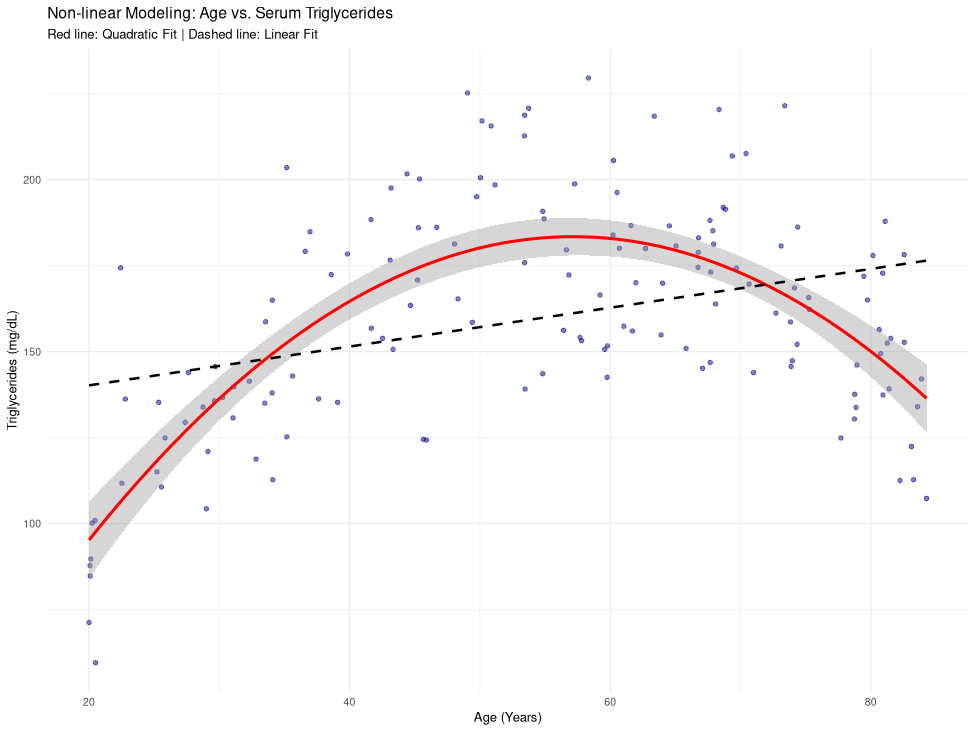

In [4]:
ggplot(df, aes(x = Age, y = Triglycerides)) +
  geom_point(alpha = 0.5, color = "darkblue") +
  # Adding the Quadratic Regression Line
  geom_smooth(method = "lm", formula = y ~ x + I(x^2), color = "red", size = 1.2) +
  # Adding the Linear Line for comparison (dashed)
  geom_smooth(method = "lm", formula = y ~ x, color = "black", linetype = "dashed", se = FALSE) +
  theme_minimal() +
  labs(title = "Non-linear Modeling: Age vs. Serum Triglycerides",
       subtitle = "Red line: Quadratic Fit | Dashed line: Linear Fit",
       x = "Age (Years)",
       y = "Triglycerides (mg/dL)")